In [1]:
import geopandas as gpd
import libpysal
import numpy as np
import spreg
import statsmodels.formula.api as smf
from esda.moran import Moran

In [2]:
df_samples = gpd.read_file("./df_samples.gpkg")
df_matched = gpd.read_file("./df_matched.gpkg").assign(
    slope_binned=lambda df: df["slope"].apply(lambda x: min(5, x)),
    lights_log=lambda df: np.log(df["lights"]),
)
df_matched.to_file("./df_matched_fixed.gpkg")

In [15]:
model_simple = smf.ols("temp ~ type", data=df_matched).fit()
print(model_simple.summary())

                            OLS Regression Results                            
Dep. Variable:                   temp   R-squared:                       0.045
Model:                            OLS   Adj. R-squared:                  0.043
Method:                 Least Squares   F-statistic:                     21.74
Date:                Fri, 15 May 2026   Prob (F-statistic):           4.08e-06
Time:                        11:33:04   Log-Likelihood:                -1062.2
No. Observations:                 468   AIC:                             2128.
Df Residuals:                     466   BIC:                             2137.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     35.1511      0.153    229.156      0.0

<Axes: ylabel='Frequency'>

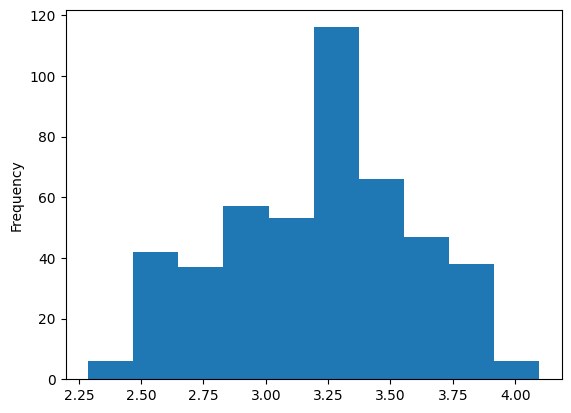

In [11]:
df_matched["lights_log"].plot.hist()

In [19]:
model_robust = smf.ols(
    "temp ~ type + elevation + C(slope_binned) + lights_log + landuse_park + landuse_mixed_use + landuse_non_residential + landuse_residential",
    data=df_matched,
).fit(cov_type="HC3")
print(model_robust.summary())

                            OLS Regression Results                            
Dep. Variable:                   temp   R-squared:                       0.448
Model:                            OLS   Adj. R-squared:                  0.435
Method:                 Least Squares   F-statistic:                     32.08
Date:                Fri, 15 May 2026   Prob (F-statistic):           3.60e-50
Time:                        11:37:31   Log-Likelihood:                -933.76
No. Observations:                 468   AIC:                             1892.
Df Residuals:                     456   BIC:                             1941.
Df Model:                          11                                         
Covariance Type:                  HC3                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

# Residuals

In [ ]:
W = libpysal.weights.KNN.from_dataframe(df_matched, k=5)
W.transform = "r"

residuals = model_robust.resid
moran_test = Moran(residuals, W)

print(f"Moran's I: {moran_test.I:.4f}")
print(f"P-value: {moran_test.p_sim:.4f}")

Moran's I: 0.4018
P-value: 0.0010


c:\Users\lain\Documents\belo_horizonte\.venv\lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 7 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


In [6]:
y = df_matched["temp"].to_numpy()
df_x = df_matched.drop(
    columns=["geometry", "temp", "landuse_park", "lights", "slope", "pair_id"]
)
cols = df_x.columns.tolist()
X = df_x.to_numpy()

In [7]:
sem_model = spreg.GM_Error_Het(y, X, w=W, name_y="temperature", name_x=cols)

print(sem_model.summary)

GM_Error_Het
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: GM SPATIALLY WEIGHTED LEAST SQUARES (HET)
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  : temperature                Number of Observations:         468
Mean dependent var  :     34.6453                Number of Variables   :           9
S.D. dependent var  :      2.3980                Degrees of Freedom    :         459
Pseudo R-squared    :      0.4112
N. of iterations    :           1                Step1c computed       :          No

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
------------------------------------------------------------------------------------
            CONSTANT        32.21685         2.28361        14.10788         0.00000
           elevatio

In [12]:
type_index = cols.index("type") + 1

# 2. EXTRACT SPREG VALUES
spreg_coef = sem_model.betas[type_index][0]
spreg_std_err = sem_model.std_err[type_index]

# 3. CALCULATE SPREG CONFIDENCE INTERVALS
spreg_lower = spreg_coef - (1.96 * spreg_std_err)
spreg_upper = spreg_coef + (1.96 * spreg_std_err)

print(f"SEM Coefficient: {spreg_coef:.4f}")
print(f"SEM 95% CI: [{spreg_lower:.4f}, {spreg_upper:.4f}]")

SEM Coefficient: -0.6352
SEM 95% CI: [-1.1371, -0.1334]
